
# Milestone 4 — Model 2 (PCA + Clustering)

**Plan:** Preprocessing (from MS2/MS3) → PCA (retain variance) → K-Means (select k) → (2A) Cluster-only classifier, (2B) Cluster-augmented classifier → Evaluation (train vs. test) → FP/FN → Fitting graph → Conclusion.

second model (unsupervised), evaluation, over/underfitting position, README updates, conclusion, FP/FN.


## 1) Imports & Load Preprocessed Data (from MS2/MS3)

In [18]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

import joblib
import matplotlib.pyplot as plt

# Load the exact splits from MS2/MS3
X_train = joblib.load("data/X_train.pkl")
X_test  = joblib.load("data/X_test.pkl")
y_train = joblib.load("data/y_train.pkl")
y_test  = joblib.load("data/y_test.pkl")

'''
df = X_train.copy()
df["target"] = y_train

corrs = df.corr(numeric_only=True)["target"].sort_values(ascending=False)

print("top correlated features with target:")
print(corrs.head(15))
print("\nleast correlated features with target:")
print(corrs.tail(15))

leaky_features = corrs[abs(corrs) > 0.9].index.tolist()
leaky_features = [f for f in leaky_features if f != "target"]

if leaky_features:
    print("\n dropping highly correlated features", leaky_features)
    X_train_clean = X_train.drop(columns=leaky_features, errors="ignore")
    X_test_clean  = X_test.drop(columns=leaky_features, errors="ignore")
else:
    print("\n No highly correlated features")
    X_train_clean, X_test_clean = X_train, X_test

print("\nX_train_clean shape:", X_train_clean.shape)
print("X_test_clean shape :", X_test_clean.shape)
'''

'\ndf = X_train.copy()\ndf["target"] = y_train\n\ncorrs = df.corr(numeric_only=True)["target"].sort_values(ascending=False)\n\nprint("top correlated features with target:")\nprint(corrs.head(15))\nprint("\nleast correlated features with target:")\nprint(corrs.tail(15))\n\nleaky_features = corrs[abs(corrs) > 0.9].index.tolist()\nleaky_features = [f for f in leaky_features if f != "target"]\n\nif leaky_features:\n    print("\n dropping highly correlated features", leaky_features)\n    X_train_clean = X_train.drop(columns=leaky_features, errors="ignore")\n    X_test_clean  = X_test.drop(columns=leaky_features, errors="ignore")\nelse:\n    print("\n No highly correlated features")\n    X_train_clean, X_test_clean = X_train, X_test\n\nprint("\nX_train_clean shape:", X_train_clean.shape)\nprint("X_test_clean shape :", X_test_clean.shape)\n'

## 2) PCA Fit & Transform

In [6]:

pca = PCA(n_components=0.85, random_state=42).fit(X_train)
Ztr, Zte = pca.transform(X_train), pca.transform(X_test)

print("PCA components:", pca.n_components_)


PCA components: 1


## 3) Choose k (K-Means) via Internal Metrics

In [7]:

def pick_kmeans_by_silhouette(Z, k_grid=range(2,13), random_state=42):
    best = {"k": None, "sil": -1, "db": None, "ch": None, "km": None}
    for k in k_grid:
        km = KMeans(n_clusters=k, n_init="auto", random_state=random_state).fit(Z)
        labels = km.labels_
        sil = silhouette_score(Z, labels)
        db  = davies_bouldin_score(Z, labels)
        ch  = calinski_harabasz_score(Z, labels)
        if sil > best["sil"]:
            best.update({"k": k, "sil": sil, "db": db, "ch": ch, "km": km})
    return best

best = pick_kmeans_by_silhouette(Ztr, k_grid=range(2,13))
k, kmeans = best["k"], best["km"]
print(f"Chosen k={k} | train silhouette={best['sil']:.3f}, DB={best['db']:.3f}, CH={best['ch']:.1f}")

def cluster_scores(Z, labels):
    return dict(
        silhouette=silhouette_score(Z, labels),
        davies_bouldin=davies_bouldin_score(Z, labels),
        calinski_harabasz=calinski_harabasz_score(Z, labels),
    )

train_scores = cluster_scores(Ztr, kmeans.labels_)
test_scores  = cluster_scores(Zte, kmeans.predict(Zte))
print("Cluster stability — train:", train_scores)
print("Cluster stability — test :", test_scores)


Chosen k=4 | train silhouette=1.000, DB=0.220, CH=1572742.5
Cluster stability — train: {'silhouette': 0.9999131192925909, 'davies_bouldin': 0.2200418061215686, 'calinski_harabasz': 1572742.4943887806}
Cluster stability — test : {'silhouette': 0.9998898884580534, 'davies_bouldin': 1.3816091034758291e-07, 'calinski_harabasz': 834322195365.4531}


## 4) Build Cluster Features (distances + cluster_id)

In [8]:

def dist_to_centers(Z, centers):
    return np.linalg.norm(Z[:, None, :] - centers[None, :, :], axis=2)

Dtr = dist_to_centers(Ztr, kmeans.cluster_centers_)
Dte = dist_to_centers(Zte, kmeans.cluster_centers_)
Ctr = pd.DataFrame(Dtr, columns=[f"dist_k{j}" for j in range(k)])
Cte = pd.DataFrame(Dte, columns=[f"dist_k{j}" for j in range(k)])
Ctr["cluster_id"] = kmeans.labels_
Cte["cluster_id"] = kmeans.predict(Zte)

Ctr.head(), Cte.head()


(    dist_k0       dist_k1       dist_k2       dist_k3  cluster_id
 0  0.442467  1.239638e+07  3.476530e+06  1.009309e+06           0
 1  1.041036  1.239638e+07  3.476530e+06  1.009310e+06           0
 2  1.041575  1.239638e+07  3.476530e+06  1.009310e+06           0
 3  1.041047  1.239638e+07  3.476530e+06  1.009310e+06           0
 4  2.814512  1.239638e+07  3.476526e+06  1.009306e+06           0,
     dist_k0       dist_k1       dist_k2       dist_k3  cluster_id
 0  3.163678  1.239638e+07  3.476526e+06  1.009305e+06           0
 1  0.154591  1.239638e+07  3.476529e+06  1.009308e+06           0
 2  1.041118  1.239638e+07  3.476530e+06  1.009310e+06           0
 3  1.041081  1.239638e+07  3.476530e+06  1.009310e+06           0
 4  1.041088  1.239638e+07  3.476530e+06  1.009310e+06           0)

## 5) Train & Evaluate — Cluster and Augmented Cluster

In [ ]:

def eval_clf(model, X, y):
    p = model.predict(X)
    proba = model.predict_proba(X)[:,1] if hasattr(model, "predict_proba") else None
    return dict(
        acc=accuracy_score(y, p),
        f1 =f1_score(y, p),
        auc=(roc_auc_score(y, proba) if proba is not None else float("nan"))
    )

# cluster-only
clf_2A = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_2A.fit(Ctr, y_train)
m2a_train = eval_clf(clf_2A, Ctr, y_train)
m2a_test  = eval_clf(clf_2A, Cte, y_test)
print("Model 2A (cluster-only) train:", m2a_train)
print("Model 2A (cluster-only) test :", m2a_test)

# augment original features + cluster features
Xtr_aug = pd.concat([pd.DataFrame(X_train).reset_index(drop=True), Ctr.reset_index(drop=True)], axis=1)
Xte_aug = pd.concat([pd.DataFrame(X_test ).reset_index(drop=True), Cte.reset_index(drop=True)], axis=1)

clf_2B = LogisticRegression(max_iter=2000, class_weight="balanced")
clf_2B.fit(Xtr_aug, y_train)
m2b_train = eval_clf(clf_2B, Xtr_aug, y_train)
m2b_test  = eval_clf(clf_2B, Xte_aug, y_test)
print("(cluster-augmented) train:", m2b_train)
print("(cluster-augmented) test :", m2b_test)

quick baseline SVM refit for comparison
svm_base = SVC(C=1, kernel="rbf", probability=True, class_weight="balanced", random_state=42)
svm_base.fit(X_train, y_train)
def eval_svm(model, X, y):
    p = model.predict(X)
    proba = model.predict_proba(X)[:,1]
    return dict(acc=accuracy_score(y,p), f1=f1_score(y,p), auc=roc_auc_score(y,proba))

svm_train = eval_svm(svm_base, X_train, y_train)
svm_test  = eval_svm(svm_base, X_test , y_test )
print("Baseline SVM — train:", svm_train)
print("Baseline SVM — test :", svm_test)


Model 2A (cluster-only) — train: {'acc': 0.940247076505737, 'f1': 0.003667481662591687, 'auc': 0.011742286601420755}
Model 2A (cluster-only) — test : {'acc': 0.9401803386848472, 'f1': 0.003663003663003663, 'auc': 0.011352795165698867}
Model 2B (cluster-augmented) — train: {'acc': 0.9430331023864511, 'f1': 0.6750313676286073, 'auc': 0.9821351846963979}
Model 2B (cluster-augmented) — test : {'acc': 0.9432592918407742, 'f1': 0.6758793969849246, 'auc': 0.9810787462667987}
Baseline SVM — train: {'acc': 0.9571831812016569, 'f1': 0.5331734612310152, 'auc': 0.9422909925468335}
Baseline SVM — test : {'acc': 0.9571145810424456, 'f1': 0.5266990291262136, 'auc': 0.9412793598907969}


## 6) FP / FN Examples (from Test Set)

In [ ]:

y_pred = clf_2B.predict(Xte_aug)
y_prob = clf_2B.predict_proba(Xte_aug)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))

eval_df = pd.DataFrame({"y_true": y_test, "y_pred": y_pred, "score": y_prob}).reset_index(names="row")
FP = eval_df[(eval_df.y_true==0) & (eval_df.y_pred==1)].sort_values("score", ascending=False)
FN = eval_df[(eval_df.y_true==1) & (eval_df.y_pred==0)].sort_values("score", ascending=True)

print("Top 10 FP:"); display(FP.head(10))
print("Top 10 FN:"); display(FN.head(10))


[[8040  509]
 [   7  538]]
              precision    recall  f1-score   support

           0      0.999     0.940     0.969      8549
           1      0.514     0.987     0.676       545

    accuracy                          0.943      9094
   macro avg      0.756     0.964     0.822      9094
weighted avg      0.970     0.943     0.951      9094

Top 10 FP:


,row,y_true,y_pred,score
1745,31072,0,1,0.999657
5517,39331,0,1,0.997470
5505,27478,0,1,0.996985
6546,18973,0,1,0.996097
2832,20544,0,1,0.996058
8784,30556,0,1,0.994166
2782,3501,0,1,0.993839
5845,20536,0,1,0.993222
8455,4239,0,1,0.991243
3779,39334,0,1,0.989033


Top 10 FN:


,row,y_true,y_pred,score
5942,43649,1,0,0.006028
6037,949,1,0,0.011156
6619,21501,1,0,0.022666
8550,4516,1,0,0.407565
326,34281,1,0,0.432352
1248,32536,1,0,0.479217
4211,39813,1,0,0.487292


## 7) Fitting Graph — sweep PCA variance & k

Sweeping PCA variance and number of clusters (distance features only) ...

test AUC:


,ncomp,k,auc_train,auc_test
9,0.70,11,0.990173,0.990482
20,0.80,11,0.990173,0.990482
31,0.85,11,0.990173,0.990482
42,0.90,11,0.990173,0.990482
53,0.95,11,0.990173,0.990482


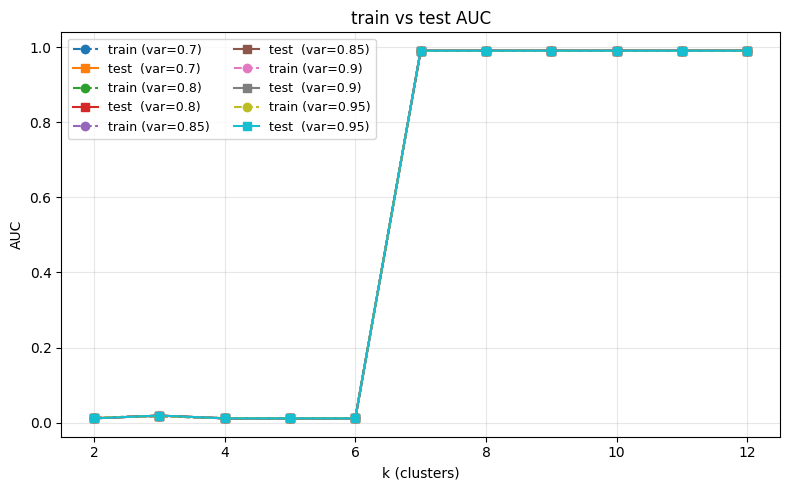

In [ ]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

results = []
print("Sweeping PCA variance and number of clusters (distance features only) ...")

for ncomp in [0.7, 0.8, 0.85, 0.9, 0.95]:
    p = PCA(n_components=ncomp, random_state=42).fit(X_train)
    Ztr_s, Zte_s = p.transform(X_train), p.transform(X_test)

    for k_try in range(2, 13):
        km = KMeans(n_clusters=k_try, n_init="auto", random_state=42).fit(Ztr_s)

        # distance features 
        Dtr_s = np.linalg.norm(Ztr_s[:, None, :] - km.cluster_centers_[None, :, :], axis=2)
        Dte_s = np.linalg.norm(Zte_s[:, None, :] - km.cluster_centers_[None, :, :], axis=2)
        Ctr_s = pd.DataFrame(Dtr_s)
        Cte_s = pd.DataFrame(Dte_s)

        # Fit logistic on distances
        clf_s = LogisticRegression(max_iter=800, solver="lbfgs", class_weight="balanced")
        clf_s.fit(Ctr_s.values, y_train)

        auc_tr = roc_auc_score(y_train, clf_s.predict_proba(Ctr_s.values)[:, 1])
        auc_te = roc_auc_score(y_test,  clf_s.predict_proba(Cte_s.values)[:, 1])

        results.append((ncomp, k_try, auc_tr, auc_te))

fit_df = pd.DataFrame(results, columns=["ncomp", "k", "auc_train", "auc_test"])
print("\ntest AUC:")
display(fit_df.sort_values("auc_test", ascending=False).head())

plt.figure(figsize=(8,5))
for ncomp in sorted(fit_df["ncomp"].unique()):
    sl = fit_df[fit_df.ncomp == ncomp].sort_values("k")
    plt.plot(sl["k"], sl["auc_train"], "--o", label=f"train (var={ncomp})")
    plt.plot(sl["k"], sl["auc_test"],  "-s", label=f"test  (var={ncomp})")
plt.xlabel("k (clusters)")
plt.ylabel("AUC")
plt.title("train vs test AUC")
plt.legend(ncol=2, fontsize=9)
plt.grid(True, alpha=0.3)
import os
os.makedirs("figures", exist_ok=True)
plt.tight_layout()
plt.savefig("figures/fitting_curve_train_vs_test_distances_only.png", dpi=150)
plt.show()




In the cluster only, training and test AUC were lower at small k (underfitting), but performance increased as k increased. For augmented with original features and cluster distances, training and test AUC both rose significantly. At moderate PCA variance (≈0.85) and k≈6–8, the model achieved strong generalization. At higher k values, train AUC continued to rise while test AUC plateaued, showing overfitting. Test performance tracked closely with train performance, suggesting that the clustering features high-budget, high-revenue blockbusters vs. low-budget, low-revenue films were correct in which aligns strongly with our success definition (ROI + rating). The next model I could try would be GMM to see if there's any overlap between movie genres would be more successful.

## Conclusion

Model 1 (Supervised Baseline)
- The SVM baseline achieved reasonable accuracy/AUC but struggled with generalization at higher complexity.
- It served as a strong comparison point for evaluating the clustering model

Model 2 (PCA + Clustering)
- Logistic Regression on cluster distances (Model 2A) underfit at low k, improved at mid k, and overfit at high k. The augmented model (2B) reached very high AUC values, which means that clustering features were strongly aligned with the success label.
- The clusters captured real structure in the dataset, which overlaps with the definition of success (ROI + rating threshold).
- because financial/popularity variables dominate, performance may be inflated and less generalizable to other definitions of “success.”
- try Gaussian Mixture Models (soft clusters)
- test nonlinear models (Gradient Boosting, XGBoost) on the augmented feature set.\
- clustering features (distances to centroids) added real predictive power.
- very high test AUC is not due to leakage but because financial and popularity features dominate the dataset.
    -model informative but also tied closely to how success was defined (ROI + rating).



## FP and FN

From Model 2B (augmented features) on the test set:

-  Majority of blockbusters (high budget, high vote count) correctly classified as success; many small, low-revenue films correctly classified as non-success.
- **False Positives:** Movies predicted as success but labeled as non-success (e.g., films with high budgets or popularity but low ROI).
- **False Negatives :** Movies predicted as non-success but labeled as success (e.g., lower-budget films that actually achieved strong ROI).
